# Double Exponential (Laplace) Distribution

The **Double Exponential (Laplace) distribution** looks like two Exponential distributions placed back-to-back. It is symmetric like the Normal but has a sharper peak and **heavier tails** (kurtosis=6 vs 3). It arises in L1 regression (least absolute deviations) and is the likelihood model behind the LASSO regulariser.

| Property | Value |
|---|---|
| **Parameters** | $\mu$ (location), $\beta$ (scale, $\beta > 0$) |
| **Support** | $(-\infty, +\infty)$ |
| **PDF** | $f(x) = \dfrac{1}{2\beta} \exp\!\left(-\dfrac{|x-\mu|}{\beta}\right)$ |
| **CDF** | $F(x) = \tfrac{1}{2} + \tfrac{1}{2}\,\text{sign}(x-\mu)\left(1 - e^{-|x-\mu|/\beta}\right)$ |
| **Mean** | $\mu$ |
| **Median** | $\mu$ |
| **Std Dev** | $\sqrt{2}\,\beta$ |
| **Skewness** | $0$ (symmetric) |
| **Kurtosis** | $6$ (heavier tails than Normal) |
| **Estimation** | $\hat{\mu} =$ sample median (MLE); $\hat{\beta} = \overline{|x_i - \hat{\mu}|}$ |
| **LASSO link** | Laplace prior on coefficients → L1 regularisation |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Visualising the Double Exponential (Laplace) Distribution

### Panel 1 — PDF vs Normal
The **Laplace PDF** $f(x) = \frac{1}{2\beta}e^{-|x-\mu|/\beta}$ has a characteristic sharp peak and heavier tails than the Normal. The comparison uses the same standard deviation to isolate the effect of the tail shape.

### Panel 2 — Log PDF Comparison (Tail Decay)
On a log scale, the Normal tail decays as $-x^2$ (quadratic, very fast), while the Laplace tail decays as $-|x|$ (linear, much slower). This confirms the Laplace's heavier tails and explains why outliers are more probable.

### Panel 3 — Sample Mean vs Sample Median as Location Estimators
500 repeated experiments compare the standard error of the **sample mean** vs the **sample median** for Laplace data. The median has a lower standard error, confirming it is the MLE and minimum-variance estimator for Laplace location.


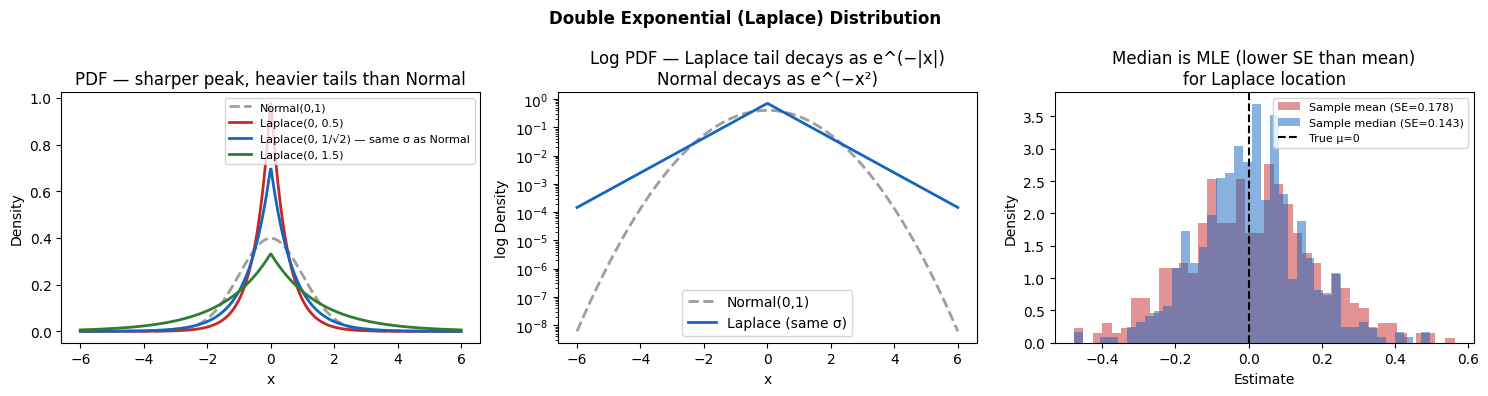

MLE for Laplace is the sample median (not the mean)
Mean SE=0.1782  vs  Median SE=0.1434


In [2]:
x = np.linspace(-6, 6, 500)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Double Exponential (Laplace) Distribution', fontsize=12, fontweight='bold')

# PDF vs Normal
axes[0].plot(x, stats.norm(0,1).pdf(x), color='#9E9E9E', linewidth=2, linestyle='--', label='Normal(0,1)')
for beta, color, label in [(0.5, '#C62828', 'Laplace(0, 0.5)'),
                             (1/np.sqrt(2), '#1565C0', 'Laplace(0, 1/√2) — same σ as Normal'),
                             (1.5, '#2E7D32', 'Laplace(0, 1.5)')]:
    axes[0].plot(x, stats.laplace(loc=0, scale=beta).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — sharper peak, heavier tails than Normal')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Log-scale comparison of tails
axes[1].semilogy(x, stats.norm(0,1).pdf(x), color='#9E9E9E', linewidth=2,
                 linestyle='--', label='Normal(0,1)')
axes[1].semilogy(x, stats.laplace(0, 1/np.sqrt(2)).pdf(x), color='#1565C0', linewidth=2,
                 label='Laplace (same σ)')
axes[1].set_title('Log PDF — Laplace tail decays as e^(−|x|)\nNormal decays as e^(−x²)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('log Density')
axes[1].legend()

# MLE vs mean for location estimation
np.random.seed(42)
n_trials = 500
n_obs = 50
mean_ests = []
median_ests = []
for _ in range(n_trials):
    samp = stats.laplace(loc=0, scale=1).rvs(n_obs)
    mean_ests.append(samp.mean())
    median_ests.append(np.median(samp))

axes[2].hist(mean_ests, bins=40, alpha=0.5, density=True, color='#C62828', label=f'Sample mean (SE={np.std(mean_ests):.3f})')
axes[2].hist(median_ests, bins=40, alpha=0.5, density=True, color='#1565C0', label=f'Sample median (SE={np.std(median_ests):.3f})')
axes[2].axvline(0, color='black', linewidth=1.5, linestyle='--', label='True μ=0')
axes[2].set_title('Median is MLE (lower SE than mean)\nfor Laplace location')
axes[2].set_xlabel('Estimate'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("MLE for Laplace is the sample median (not the mean)")
print(f"Mean SE={np.std(mean_ests):.4f}  vs  Median SE={np.std(median_ests):.4f}")

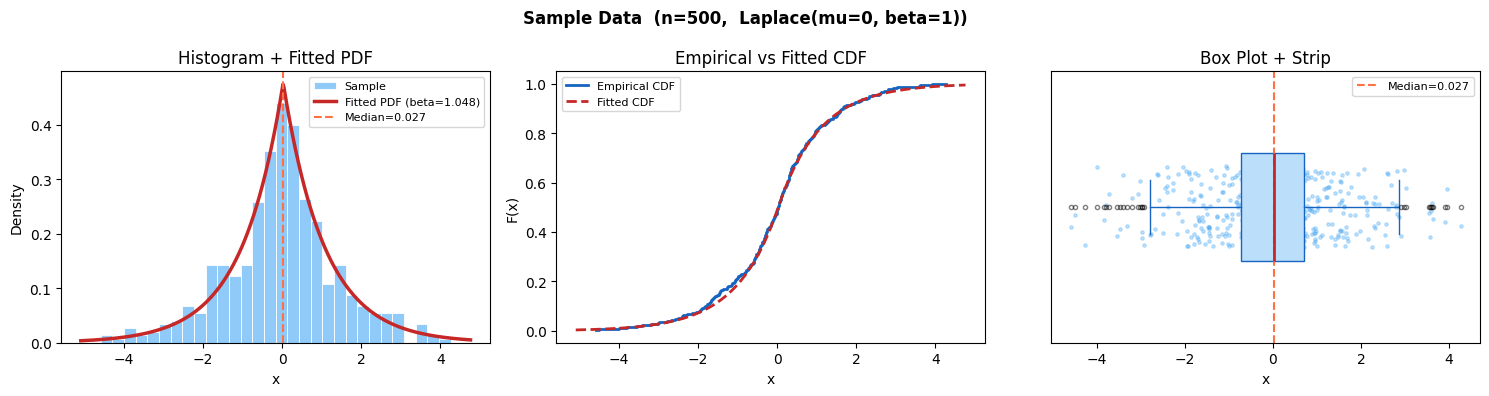

n=500  mean=-0.0265  median=0.0267  std=1.4182  skew=-0.1172  kurtosis=0.7428


In [3]:
# Sample data plots — Laplace(mu=0, beta=1)
np.random.seed(42)
sample_d = stats.laplace.rvs(loc=0, scale=1, size=500)
loc_hat, scale_hat = stats.laplace.fit(sample_d)
x_fit = np.linspace(sample_d.min() - 0.5, sample_d.max() + 0.5, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  Laplace(mu=0, beta=1))', fontsize=12, fontweight='bold')

# Histogram + fitted PDF
axes[0].hist(sample_d, bins=30, density=True,
             color='#90CAF9', edgecolor='white', linewidth=0.6, label='Sample')
axes[0].plot(x_fit, stats.laplace(loc_hat, scale_hat).pdf(x_fit),
             color='#C62828', linewidth=2.5, label=f'Fitted PDF (beta={scale_hat:.3f})')
axes[0].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[0].set_title('Histogram + Fitted PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Empirical vs fitted CDF
sorted_s = np.sort(sample_d)
ecdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].step(sorted_s, ecdf, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].plot(x_fit, stats.laplace(loc_hat, scale_hat).cdf(x_fit),
             color='#C62828', linewidth=2, linestyle='--', label='Fitted CDF')
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# Box plot + strip
axes[2].boxplot(sample_d, vert=False, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='#C62828', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                flierprops=dict(marker='o', color='#FF7043', markersize=3, alpha=0.5))
axes[2].scatter(sample_d, np.random.uniform(0.85, 1.15, len(sample_d)),
                color='#42A5F5', s=6, alpha=0.3)
axes[2].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[2].set_title('Box Plot + Strip')
axes[2].set_xlabel('x'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"n={len(sample_d)}  mean={sample_d.mean():.4f}  median={np.median(sample_d):.4f}  std={sample_d.std(ddof=1):.4f}  skew={stats.skew(sample_d):.4f}  kurtosis={stats.kurtosis(sample_d):.4f}")


## Key Takeaways

| | |
|---|---|
| **Shape** | Symmetric tent shape — sharper peak than Normal, heavier tails |
| **Kurtosis=6** | Twice the Normal kurtosis — many more extreme values |
| **MLE = median** | Minimising sum of absolute errors is MLE under Laplace noise |
| **LASSO** | Laplace prior → MAP estimate = LASSO (L1 regularised regression) |
| **Robust** | Sample median is more efficient than mean under Laplace noise |
| **vs Normal** | Normal: sum of squares (L2); Laplace: sum of absolutes (L1) |
| **Estimation** | $\hat{\mu} =$ sample median; $\hat{\beta} = \overline{|x_i - \hat{\mu}|}$ |
| **Use cases** | Error modelling in robust regression, signal processing, Bayesian LASSO |
